# Customer Life Time Value

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

In [39]:

df = pd.read_csv("OnlineRetail.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [41]:
df.shape

(541909, 8)

In [44]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],format='mixed')

In [45]:
# Remove quantities that are less than 0 (possibly returned items)
df = df.loc[df['Quantity'] > 0]

In [46]:
# Remove blank customer IDs
df = df[pd.notnull(df['CustomerID'])]

In [47]:
# View our data range
print('Date Range: %s to %s' % (df['InvoiceDate'].min(), df['InvoiceDate'].max()))

Date Range: 2010-01-12 08:26:00 to 2011-12-10 17:19:00


In [48]:
# taking all of the transactions that occurred before December 01, 2011 
df = df.loc[df['InvoiceDate'] < '2011-12-01']

In [49]:
# Create a Sales Revenue Column
df['Sales'] = df['Quantity'] * df['UnitPrice']

In [50]:
# Get a orders summary dataset that shows the total in sales made per customer invoice
orders_df = df.groupby(['CustomerID', 'InvoiceNo']).agg({'Sales': sum,'InvoiceDate': max})

In [51]:
orders_df.head(10)

Sales         InvoiceDate
CustomerID InvoiceNo                              
12346.0    541431     77183.60 2011-01-18 10:01:00
12347.0    537626       711.79 2010-07-12 14:57:00
           542237       475.39 2011-01-26 14:30:00
           549222       636.25 2011-07-04 10:43:00
           556201       382.52 2011-09-06 13:01:00
           562032       584.91 2011-02-08 08:48:00
           573511      1294.32 2011-10-31 12:25:00
           581180       224.82 2011-07-12 15:52:00
12348.0    539318       892.80 2010-12-16 19:09:00
           541998       227.44 2011-01-25 10:42:00

In [52]:
# Create some simple functions we'll be using to create our summary dataframe

df['InvoiceDate'] = df['InvoiceDate'].astype(int)

def groupby_mean(x):
    return x.mean()

def groupby_count(x):
    return x.count()

def purchase_duration(x):
    return (x.max() - x.min()).days

def avg_frequency(x):
    '''returns the average days between sales'''
    return (x.max() - x.min()).days/x.count()

groupby_mean.__name__ = 'avg'
groupby_count.__name__ = 'count'
purchase_duration.__name__ = 'purchase_duration'
avg_frequency.__name__ = 'purchase_frequency'

summary_df = orders_df.reset_index().groupby('CustomerID').agg({
    'Sales': [min, max, sum, groupby_mean, groupby_count],
    'InvoiceDate': [min, max, purchase_duration, avg_frequency]
})

In [53]:
summary_df.head(10)

Sales                                          \
                 min       max       sum           avg count   
CustomerID                                                     
12346.0     77183.60  77183.60  77183.60  77183.600000     1   
12347.0       224.82   1294.32   4310.00    615.714286     7   
12348.0       227.44    892.80   1797.24    449.310000     4   
12349.0      1757.55   1757.55   1757.55   1757.550000     1   
12350.0       334.40    334.40    334.40    334.400000     1   
12352.0       120.33    840.30   2506.04    313.255000     8   
12353.0        89.00     89.00     89.00     89.000000     1   
12354.0      1079.40   1079.40   1079.40   1079.400000     1   
12355.0       459.40    459.40    459.40    459.400000     1   
12356.0        58.35   2271.62   2811.43    937.143333     3   

                   InvoiceDate                                        \
                           min                 max purchase_duration   
CustomerID                                                             
12346.0    2011-01-18 10:01:00 2011-01-18 10:01:00                 0   
12347.0    2010-07-12 14:57:00 2011-10-31 12:25:00               475   
12348.0    2010-12-16 19:09:00 2011-09-25 13:13:00               282   
12349.0    2011-11-21 09:51:00 2011-11-21 09:51:00                 0   
12350.0    2011-02-02 16:01:00 2011-02-02 16:01:00                 0   
12352.0    2011-01-03 14:57:00 2011-09-28 14:58:00               268   
12353.0    2011-05-19 17:47:00 2011-05-19 17:47:00                 0   
12354.0    2011-04-21 13:11:00 2011-04-21 13:11:00                 0   
12355.0    2011-09-05 13:49:00 2011-09-05 13:49:00                 0   
12356.0    2011-01-18 09:50:00 2011-11-17 08:40:00               302   

                               
           purchase_frequency  
CustomerID                     
12346.0              0.000000  
12347.0             67.857143  
12348.0             70.500000  
12349.0              0.000000  
12350.0              0.000000  
12352.0             33.500000  
12353.0              0.000000  
12354.0              0.000000  
12355.0              0.000000  
12356.0            100.666667

In [54]:
# Rename our columns by combinng it with the top row
summary_df.columns = ['_'.join(col).lower() for col in summary_df.columns]

In [55]:
summary_df.head()

,sales_min,sales_max,sales_sum,sales_avg,sales_count,invoicedate_min,invoicedate_max,invoicedate_purchase_duration,invoicedate_purchase_frequency
CustomerID,,,,,,,,,
12346.0,77183.60,77183.60,77183.60,77183.600000,1,2011-01-18 10:01:00,2011-01-18 10:01:00,0,0.000000
12347.0,224.82,1294.32,4310.00,615.714286,7,2010-07-12 14:57:00,2011-10-31 12:25:00,475,67.857143
12348.0,227.44,892.80,1797.24,449.310000,4,2010-12-16 19:09:00,2011-09-25 13:13:00,282,70.500000
12349.0,1757.55,1757.55,1757.55,1757.550000,1,2011-11-21 09:51:00,2011-11-21 09:51:00,0,0.000000
12350.0,334.40,334.40,334.40,334.400000,1,2011-02-02 16:01:00,2011-02-02 16:01:00,0,0.000000


## Visualization 

In [56]:
# Let's look at the first 20 sales counts and the average spend for that sale

# We firstly group by Sales_Counts and then look at the sales_avg 
summary_df.groupby('sales_count').count()['sales_avg'][:20]

sales_count
1     1502
2      830
3      523
4      370
5      245
6      161
7      138
8       99
9       55
10      61
11      49
12      42
13      33
14      26
15      17
16      10
17      23
18      14
19      11
20       9
Name: sales_avg, dtype: int64

In [61]:

summary_df = summary_df.loc[summary_df['invoicedate_purchase_duration'] > 0]

summary_df

,sales_min,sales_max,sales_sum,sales_avg,sales_count,invoicedate_min,invoicedate_max,invoicedate_purchase_duration,invoicedate_purchase_frequency
CustomerID,,,,,,,,,
12347.0,224.82,1294.32,4310.00,615.714286,7,2010-07-12 14:57:00,2011-10-31 12:25:00,475,67.857143
12348.0,227.44,892.80,1797.24,449.310000,4,2010-12-16 19:09:00,2011-09-25 13:13:00,282,70.500000
12352.0,120.33,840.30,2506.04,313.255000,8,2011-01-03 14:57:00,2011-09-28 14:58:00,268,33.500000
12356.0,58.35,2271.62,2811.43,937.143333,3,2011-01-18 09:50:00,2011-11-17 08:40:00,302,100.666667
12359.0,1109.32,2876.85,5825.08,1941.693333,3,2011-03-06 12:26:00,2011-10-13 12:47:00,221,73.666667
...,...,...,...,...,...,...,...,...,...
18272.0,340.72,639.82,2324.92,464.984000,5,2011-04-28 18:11:00,2011-10-25 11:52:00,179,35.800000
18273.0,51.00,102.00,204.00,68.000000,3,2011-03-27 11:22:00,2011-07-12 13:16:00,107,35.666667
18282.0,77.84,100.21,178.05,89.025000,2,2011-02-12 11:43:00,2011-05-08 13:35:00,85,42.500000


Because we're trying to get the time between sales (plotted in the next cell). We need to eliminate single purchases. That's what this line does. 

`summary_df = summary_df.loc[summary_df['invoicedate_purchase_duration'] > 0]`

Purchase durations that are equal to 0 indicate that only purchase was ever made.

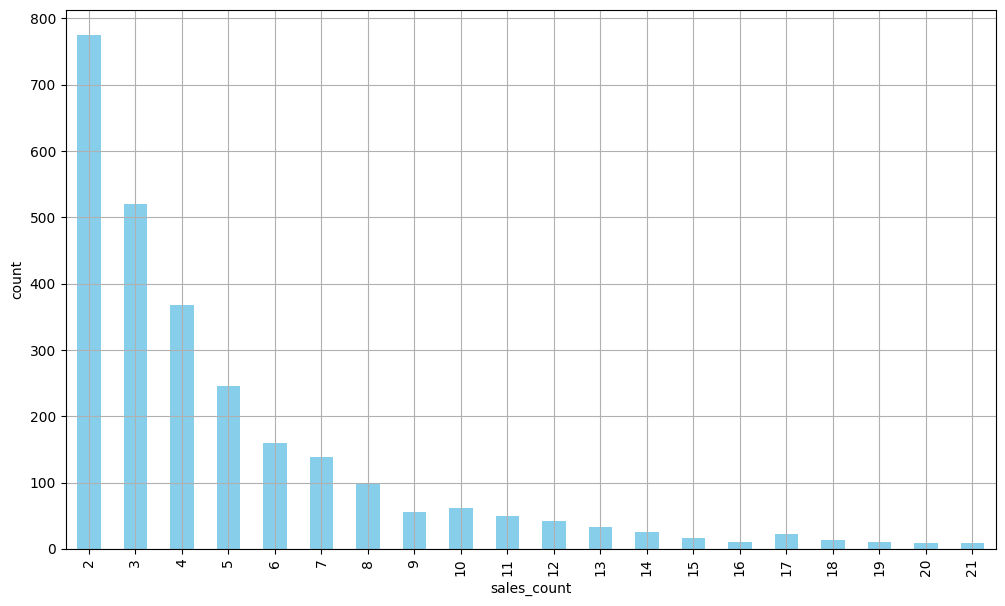

In [62]:
# We filter on invoicedate_purchase_duration greater than 0
summary_df = summary_df.loc[summary_df['invoicedate_purchase_duration'] > 0]

ax = summary_df.groupby('sales_count').count()['sales_avg'][:20].plot(kind='bar', color='skyblue',figsize=(12,7), grid=True)

ax.set_ylabel('count')

plt.show()

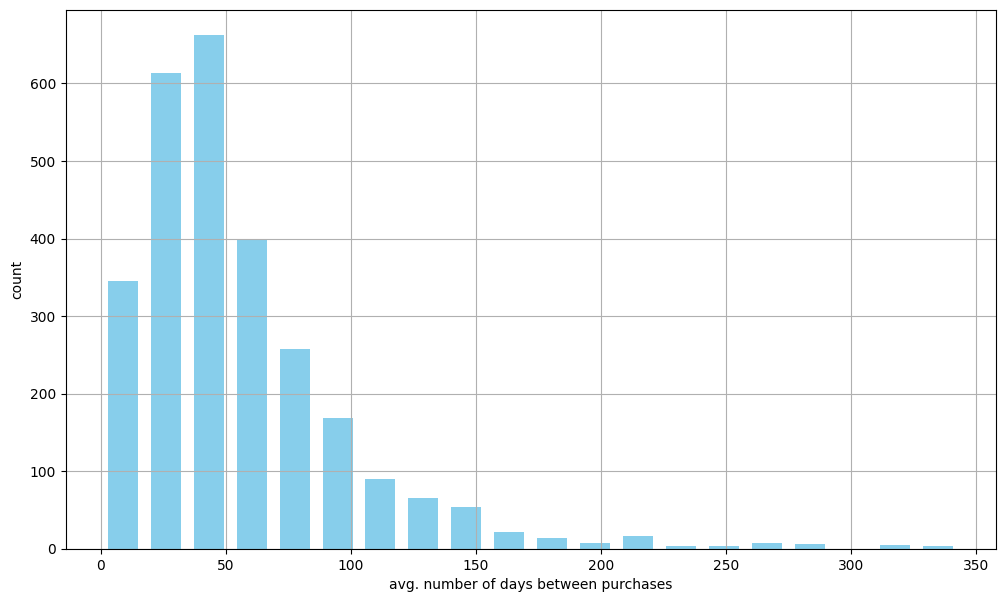

In [63]:
# Now we create a distribution for the average times between sales
ax = summary_df['invoicedate_purchase_frequency'].hist(bins=20, color='skyblue', rwidth=0.7, figsize=(12,7))

ax.set_xlabel('avg. number of days between purchases')
ax.set_ylabel('count')

plt.show()

# Predicting the 3 month Customer Lifetime Value

In [64]:
orders_df.head()

Sales         InvoiceDate
CustomerID InvoiceNo                              
12346.0    541431     77183.60 2011-01-18 10:01:00
12347.0    537626       711.79 2010-07-12 14:57:00
           542237       475.39 2011-01-26 14:30:00
           549222       636.25 2011-07-04 10:43:00
           556201       382.52 2011-09-06 13:01:00

In [66]:
# Create summary statistics in 3 month intervals for customer Sales

# Use 3M for 3 month
clv_freq = '3ME'

# Groupby customer ID now, and group all invoices for 3 month cycles.
# Aggregate on sum, mean and counts
data_df = orders_df.reset_index().groupby(['CustomerID', pd.Grouper(key='InvoiceDate', freq=clv_freq)]).agg({
    'Sales': [sum, groupby_mean, groupby_count],})

data_df.columns = ['_'.join(col).lower() for col in data_df.columns]
data_df = data_df.reset_index()
data_df.head()

,CustomerID,InvoiceDate,sales_sum,sales_avg,sales_count
0,12346.0,2011-01-31,77183.60,77183.600,1
1,12347.0,2010-07-31,711.79,711.790,1
2,12347.0,2011-01-31,475.39,475.390,1
3,12347.0,2011-04-30,584.91,584.910,1
4,12347.0,2011-07-31,861.07,430.535,2


In [67]:
# Adding Recency 'M'

# Get the M
date_month_map = {str(x)[:10]: 'M_%s' % (i+1) for i, x in enumerate(sorted(data_df.reset_index()['InvoiceDate'].unique(), reverse=True))}

# Create our M Column
data_df['M'] = data_df['InvoiceDate'].apply(lambda x: date_month_map[str(x)[:10]])
data_df.head()

,CustomerID,InvoiceDate,sales_sum,sales_avg,sales_count,M
0,12346.0,2011-01-31,77183.60,77183.600,1,M_5
1,12347.0,2010-07-31,711.79,711.790,1,M_7
2,12347.0,2011-01-31,475.39,475.390,1,M_5
3,12347.0,2011-04-30,584.91,584.910,1,M_4
4,12347.0,2011-07-31,861.07,430.535,2,M_3


In [68]:
data_df['M'].unique()

<StringArray>
['M_5', 'M_7', 'M_4', 'M_3', 'M_2', 'M_1', 'M_6', 'M_8', 'M_9']
Length: 9, dtype: str

**RFM**

By definition, RFM represents:

- R(ecency): how recently did customer purchase?
- F(rquency): how often do customer purchase?
- M(onetary Value): how much do they spend (each time on average)?

In [69]:
# Create our Features DF
features_df = pd.pivot_table(data_df.loc[data_df['M'] != 'M_1'], values=['sales_sum', 'sales_avg', 'sales_count'], columns='M', index='CustomerID')

features_df.columns = ['_'.join(col) for col in features_df.columns]

features_df.head()

,sales_avg_M_2,sales_avg_M_3,sales_avg_M_4,sales_avg_M_5,sales_avg_M_6,sales_avg_M_7,sales_avg_M_8,sales_avg_M_9,sales_count_M_2,sales_count_M_3,...,sales_count_M_8,sales_count_M_9,sales_sum_M_2,sales_sum_M_3,sales_sum_M_4,sales_sum_M_5,sales_sum_M_6,sales_sum_M_7,sales_sum_M_8,sales_sum_M_9
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,NaN,NaN,NaN,77183.600,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,77183.60,NaN,NaN,NaN,NaN
12347.0,838.42,430.535,584.9100,475.390,NaN,711.79,NaN,NaN,2.0,2.0,...,NaN,NaN,1676.84,861.07,584.91,475.39,NaN,711.79,NaN,NaN
12348.0,310.00,367.000,NaN,560.120,NaN,NaN,NaN,NaN,1.0,1.0,...,NaN,NaN,310.00,367.00,NaN,1120.24,NaN,NaN,NaN,NaN
12350.0,NaN,NaN,334.4000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,334.40,NaN,NaN,NaN,NaN,NaN
12352.0,316.25,NaN,222.2225,492.325,NaN,NaN,NaN,NaN,2.0,NaN,...,NaN,NaN,632.50,NaN,888.89,984.65,NaN,NaN,NaN,NaN


In [70]:
# Create our Response DF
response_df = data_df.loc[data_df['M'] == 'M_1', ['CustomerID', 'sales_sum']]

response_df.columns = ['CustomerID', 'CLV_'+clv_freq]
response_df.head()

,CustomerID,CLV_3ME
9,12349.0,1757.55
19,12356.0,58.35
31,12362.0,825.05
33,12363.0,299.10
41,12371.0,1527.96


In [71]:
# Create our Sample Set by merging features with response_df
sample_set_df = features_df.merge(
    response_df, 
    left_index=True, 
    right_on='CustomerID',
    how='left'
)

sample_set_df = sample_set_df.fillna(0)
sample_set_df.head()

,sales_avg_M_2,sales_avg_M_3,sales_avg_M_4,sales_avg_M_5,sales_avg_M_6,sales_avg_M_7,sales_avg_M_8,sales_avg_M_9,sales_count_M_2,sales_count_M_3,...,sales_sum_M_2,sales_sum_M_3,sales_sum_M_4,sales_sum_M_5,sales_sum_M_6,sales_sum_M_7,sales_sum_M_8,sales_sum_M_9,CustomerID,CLV_3ME
NaN,0.00,0.000,0.0000,77183.600,0.0,0.00,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,77183.60,0.0,0.00,0.0,0.0,12346.0,0.0
NaN,838.42,430.535,584.9100,475.390,0.0,711.79,0.0,0.0,2.0,2.0,...,1676.84,861.07,584.91,475.39,0.0,711.79,0.0,0.0,12347.0,0.0
NaN,310.00,367.000,0.0000,560.120,0.0,0.00,0.0,0.0,1.0,1.0,...,310.00,367.00,0.00,1120.24,0.0,0.00,0.0,0.0,12348.0,0.0
NaN,0.00,0.000,334.4000,0.000,0.0,0.00,0.0,0.0,0.0,0.0,...,0.00,0.00,334.40,0.00,0.0,0.00,0.0,0.0,12350.0,0.0
NaN,316.25,0.000,222.2225,492.325,0.0,0.00,0.0,0.0,2.0,0.0,...,632.50,0.00,888.89,984.65,0.0,0.00,0.0,0.0,12352.0,0.0


# Using Linear Regression

In [72]:
# Linear regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Our Target Variable
target_var = 'CLV_'+clv_freq

# Our Features
all_features = [x for x in sample_set_df.columns if x not in ['CustomerID', target_var]]

# Split data in Train and Test
x_train, x_test, y_train, y_test = train_test_split(sample_set_df[all_features], sample_set_df[target_var], test_size=0.3)

# Fit Model
reg_fit = LinearRegression()
reg_fit.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [73]:
# Get our y intercept
reg_fit.intercept_

np.float64(-161.9624150194886)

In [74]:
# Get our coefficents
reg_fit.coef_

array([-2.31210176e-01,  4.64780935e-01,  7.81475557e-01, -1.49925678e-01,
       -1.81198600e+00, -1.34416397e+00,  1.50182094e+00, -2.14468389e-01,
        6.70416858e+01,  6.41786790e+01, -1.18725389e+02,  3.22278100e+01,
       -1.15930655e+02,  1.53714875e+02,  9.87855644e+01,  1.15921545e+01,
        2.31180951e-01, -8.52572979e-02,  5.22450368e-02,  1.57800284e-01,
        2.17940130e+00,  9.26541323e-01, -1.10386942e+00,  1.02889179e+00])

In [75]:
# Show them here per feature
coef = pd.DataFrame(list(zip(all_features, reg_fit.coef_)))
coef.columns = ['feature', 'coef']

coef

,feature,coef
0,sales_avg_M_2,-0.231210
1,sales_avg_M_3,0.464781
2,sales_avg_M_4,0.781476
3,sales_avg_M_5,-0.149926
4,sales_avg_M_6,-1.811986
5,sales_avg_M_7,-1.344164
6,sales_avg_M_8,1.501821
7,sales_avg_M_9,-0.214468
8,sales_count_M_2,67.041686
9,sales_count_M_3,64.178679


In [76]:
# Run our input data into our model predictors
train_preds = reg_fit.predict(x_train)
test_preds = reg_fit.predict(x_test)

In [77]:
# Assess performance Training Data
from sklearn.metrics import r2_score, median_absolute_error

print(r2_score(y_true=y_train, y_pred=train_preds))
print(median_absolute_error(y_true=y_train, y_pred=train_preds))

0.7227864868362246
133.13398074087578


In [78]:
# Compare R-Squared Performance on Training and Test Datasets
print('In-Sample R-Squared: %0.4f' % r2_score(y_true = y_train, y_pred = train_preds))
print('Out-of-Sample R-Squared: %0.4f' % r2_score(y_true = y_test, y_pred = test_preds))

In-Sample R-Squared: 0.7228
Out-of-Sample R-Squared: -0.1295


In [79]:
# Compare MSE on Training and Test Datasets
print('In-Sample MSE: %0.4f' % median_absolute_error(y_true = y_train, y_pred = train_preds))
print('Out-of-Sample MSE: %0.4f' % median_absolute_error(y_true = y_test, y_pred = test_preds))

In-Sample MSE: 133.1340
Out-of-Sample MSE: 136.2379


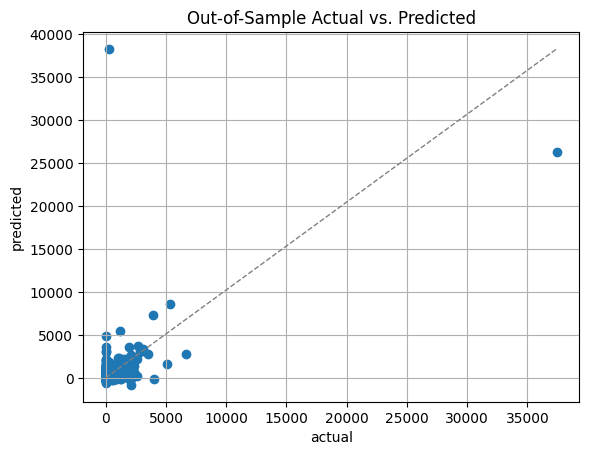

In [80]:
# Plot the predicted vs actual values using our Test Dataset
plt.scatter(y_test, test_preds)
plt.plot([0, max(y_test)], [0, max(test_preds)], color='gray', lw=1, linestyle='--')

plt.xlabel('actual')
plt.ylabel('predicted')
plt.title('Out-of-Sample Actual vs. Predicted')
plt.grid()

plt.show()